# Derivatives :)

This notebooks shows how to exploit the capabilities of the code, written in jax to perform the automatic differentiation over the implemented rate constants parametrization.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import sys
sys.path.append("/Users/tdinelli/Documents/GitHub/diffPLOG2TROE")
from diffPLOG2TROE.rate_constants import Arrhenius

import matplotlib.pyplot as plt
import equinox as eqx
import optax

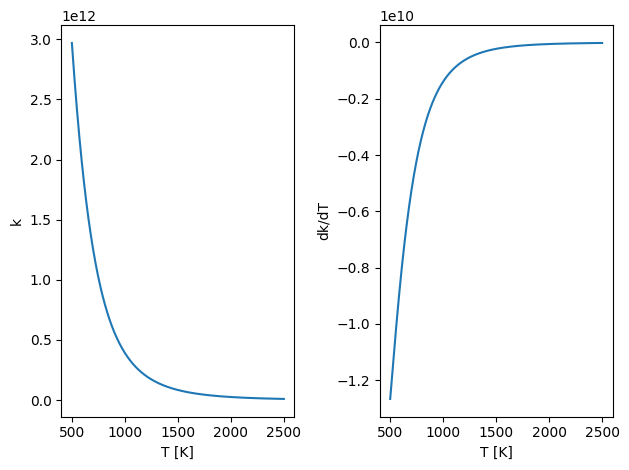

In [2]:
T_range = jnp.linspace(500, 2500, 1000)
rate_constant = {
    "name": "NH2+H=NH3",
    "type": "arrhenius",
    "rate-constant": {
        "coefficients": [1.21300e+27, -4.95900e+00, 2.80709e+03],
    },
}
rate_constant = Arrhenius(rate_constant)

K = rate_constant.kinetic_constant(T_range)
dKdT_fun = jax.vmap(jax.grad(rate_constant.kinetic_constant)) # We need vmap since we want to be able to pass directly a vector to the gradient function
dKdT = dKdT_fun(T_range)

fig, ax = plt.subplots(1, 2)

ax[0].plot(T_range, K)
ax[0].set_xlabel("T [K]")
ax[0].set_ylabel("k")
ax[1].plot(T_range, dKdT)
ax[1].set_xlabel("T [K]")
ax[1].set_ylabel("dk/dT")
plt.tight_layout()
plt.show()

## Now let's try something more "challenging" in terms of derivatives

Let's try to fit a modified arrhenius equation over some synthetic generated data with some additive noise over them. Using LBFGS as provided by optax and differentiate over the loss function.

Iteration 0, loss: 19.313511, params: [   59.73099357    -4.99067876 -1509.81389376]
Iteration 10, loss: 0.245666, params: [   63.16267596    -5.05693932 -1509.78947202]
Iteration 20, loss: 0.245666, params: [   63.17173851    -5.05806939 -1511.07263602]
Iteration 30, loss: 0.245666, params: [   63.18677635    -5.05989766 -1513.16967342]
Iteration 40, loss: 0.245666, params: [   63.18677635    -5.05989766 -1513.16967342]
Iteration 50, loss: 0.245666, params: [   63.18677635    -5.05989766 -1513.16967342]
Iteration 60, loss: 0.245666, params: [   63.18677635    -5.05989766 -1513.16967342]
Iteration 70, loss: 0.245666, params: [   63.18677635    -5.05989766 -1513.16967342]
Iteration 80, loss: 0.245666, params: [   63.18677635    -5.05989766 -1513.16967342]
Iteration 90, loss: 0.245666, params: [   63.18677635    -5.05989766 -1513.16967342]


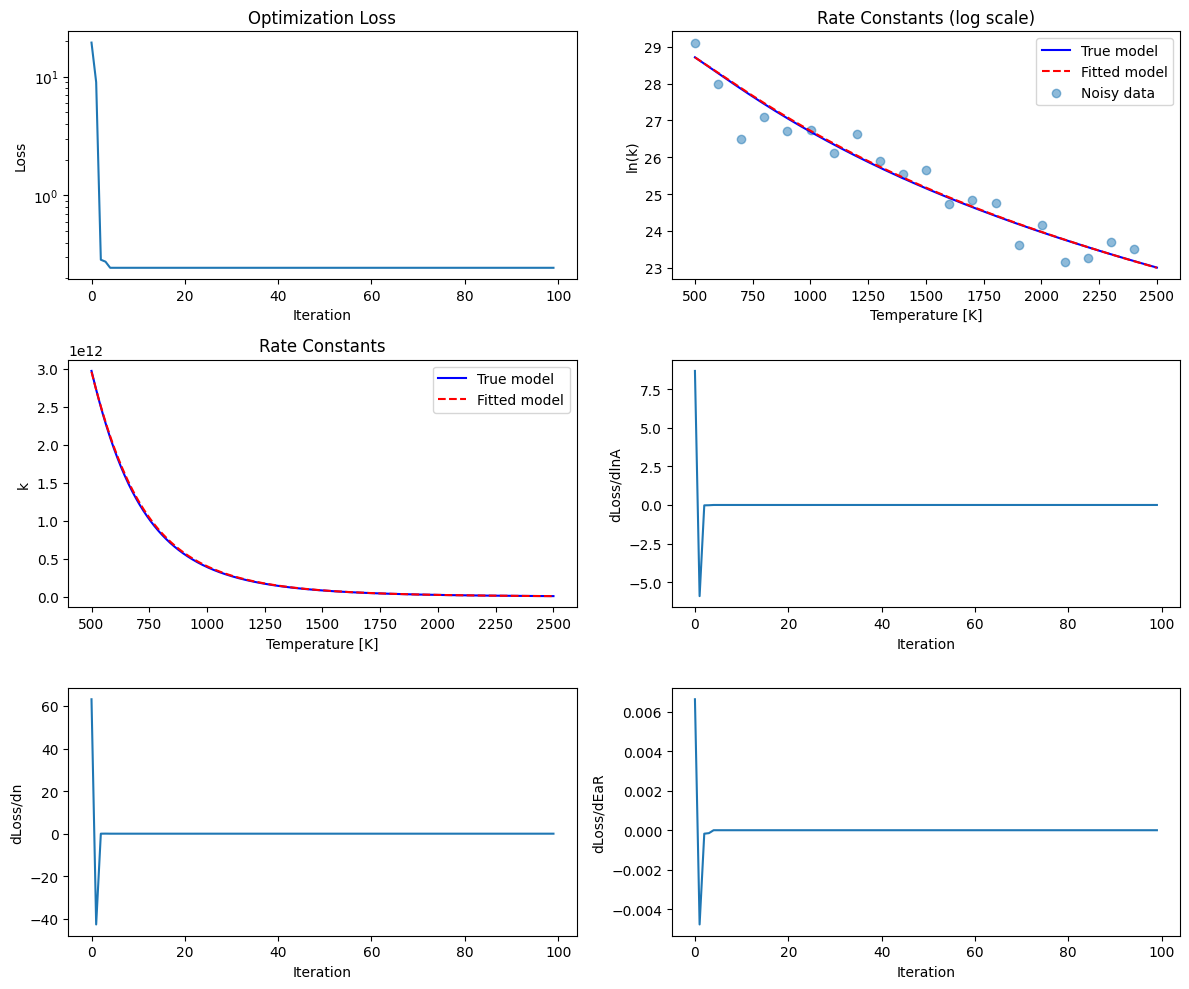

True parameters:
A = 1.213000e+27, n = -4.959000, Ea = 2807.090105

Fitted parameters:
A = 2.764829e+27, n = -5.059898, Ea = 3006.668141


In [3]:
# ================================================
# Define a loss function
def loss(params):
    """Compute the loss between data and model predictions."""
    lnA, n, EaR = params
    tmp = {
        "name": "tmp",
        "type": "arrhenius",
        "rate-constant": {
            "coefficients": [jnp.exp(lnA), n, -EaR * 1.987],
        },
    }
    arrhenius = Arrhenius(tmp)
    k_pred = arrhenius.kinetic_constant(T_range)
    log_k_pred = jnp.log(k_pred)
    loss = jnp.mean((log_k_noisy - log_k_pred) ** 2)
    return loss
    
# ================================================
# Define a step function for the optimization
@jax.jit
def step(params, opt_state):
    """Single optimization step using LBFGS."""
    value, grad = jax.value_and_grad(loss)(params)
    updates, opt_state = optimizer.update(
        updates=grad,
        state=opt_state,
        params=params,
        value=value,
        grad=grad,
        value_fn=loss
    )

    params = optax.apply_updates(params, updates)
    return params, opt_state, value, grad

T_range = jnp.linspace(500, 2500, 1000)
key = jax.random.PRNGKey(42)
true_model = {
    "name": "NH2+H=NH3",
    "type": "arrhenius",
    "rate-constant": {
        "coefficients": [1.21300e+27, -4.95900e+00, 2.80709e+03],
    },
}
true_rate = Arrhenius(true_model)
k_true = true_rate.kinetic_constant(T_range)
log_k_true = jnp.log(k_true)
noise = jax.random.normal(key, shape=log_k_true.shape) * 0.5
log_k_noisy = log_k_true + noise

# ================================================
# Initial guess (deliberately different from true values)
initial_params = jnp.array([jnp.log(1.0e+26), -4.0, -3000.0 / 1.987])

# ================================================
# Optimization
optimizer = optax.lbfgs(
    # max_iterations=50,  # Inner iterations of the line search
    # linesearch=optax.scale_by_zoom_linesearch(max_linesearch_steps=20)
)

# ================================================
# Initialize optimizer state
opt_state = optimizer.init(initial_params)

# ================================================
# Run the optimization
losses = []
grad_history = []
params = initial_params
for i in range(100): # Let's run 100 iterations
    params, opt_state, loss_value, grad = step(params, opt_state)
    losses.append(loss_value)
    grad_history.append(grad)
    if i % 10 == 0:
        print(f"Iteration {i}, loss: {loss_value:.6f}, params: {params}")

grad_history_array = jnp.array(grad_history)

fitted_model = Arrhenius({
    "name": "fitted_model",
    "type": "arrhenius",
    "rate-constant": {
        "coefficients": jnp.array([jnp.exp(params[0]), params[1], -params[2] * 1.987]) ,
    },
})

# ================================================
# Calculate rate constants and their derivatives
k_true = true_rate.kinetic_constant(T_range)
k_fitted = fitted_model.kinetic_constant(T_range)

# ================================================
# Plot the results
fig, axs = plt.subplots(3, 2, figsize=(12, 10))

# Plot the loss during optimization
axs[0, 0].plot(losses)
axs[0, 0].set_xlabel('Iteration')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].set_title('Optimization Loss')
axs[0, 0].set_yscale('log')

# ================================================
# Plot the rate constants
axs[0, 1].plot(T_range, jnp.log(k_true), 'b-', label='True model')
axs[0, 1].plot(T_range, jnp.log(k_fitted), 'r--', label='Fitted model')
axs[0, 1].scatter(T_range[::50], log_k_noisy[::50], alpha=0.5, label='Noisy data')
axs[0, 1].set_xlabel('Temperature [K]')
axs[0, 1].set_ylabel('ln(k)')
axs[0, 1].set_title('Rate Constants (log scale)')
axs[0, 1].legend()

# ================================================
# Plot the rate constants in original scale
axs[1, 0].plot(T_range, k_true, 'b-', label='True model')
axs[1, 0].plot(T_range, k_fitted, 'r--', label='Fitted model')
axs[1, 0].set_xlabel('Temperature [K]')
axs[1, 0].set_ylabel('k')
axs[1, 0].set_title('Rate Constants')
axs[1, 0].legend()

# ================================================
# Plot the derivatives
axs[1, 1].plot(grad_history_array[:, 0])
axs[1, 1].set_xlabel('Iteration')
axs[1, 1].set_ylabel('dLoss/dlnA')

axs[2, 0].plot(grad_history_array[:, 1])
axs[2, 0].set_xlabel('Iteration')
axs[2, 0].set_ylabel('dLoss/dn')

axs[2, 1].plot(grad_history_array[:, 2])
axs[2, 1].set_xlabel('Iteration')
axs[2, 1].set_ylabel('dLoss/dEaR')

plt.tight_layout()
plt.show()

# ================================================
# Print the results
print("True parameters:")
print(f"A = {jnp.exp(true_rate.lnA):.6e}, n = {true_rate.n:.6f}, Ea = {true_rate.EaR * 1.987:.6f}")
print("\nFitted parameters:")
print(f"A = {jnp.exp(params[0]):.6e}, n = {params[1]:.6f}, Ea = {-params[2] * 1.987:.6f}")